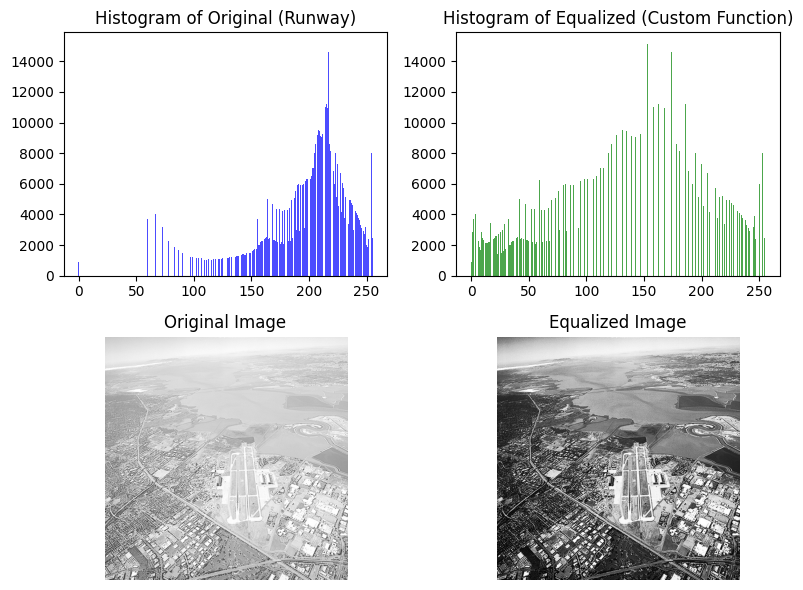

In [3]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

def equalizeHistogram(image):
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype(np.uint8)
    
    return cdf[image]

im = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert im is not None, 'Image not found'

new_im = equalizeHistogram(im)

hist_im = cv.calcHist([im], [0], None, [256], [0, 256]).flatten()
hist_new_im = cv.calcHist([new_im], [0], None, [256], [0, 256]).flatten()

fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].set_title('Histogram of Original (Runway)')
ax[0, 0].bar(range(256), hist_im, color='blue', alpha=0.7)

ax[0, 1].set_title('Histogram of Equalized (Custom Function)')
ax[0, 1].bar(range(256), hist_new_im, color='green', alpha=0.7)

ax[1, 0].set_title('Original Image')
ax[1, 0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[1, 0].axis('off')

ax[1, 1].set_title('Equalized Image')
ax[1, 1].imshow(new_im, cmap='gray', vmin=0, vmax=255)
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()